In [1]:
from nichenetpy.utils import (
    read_csv_cols,
    combine_dicts
)
from nichenetpy.model_construction import (
    construct_weighted_networks,
    apply_hub_correction,
    construct_ligand_target_matrix
)
from nichenetpy.prediction import LigandActivityPredictor
from nichenetpy.network import LigandReceptorNetwork, WeightedNetwork

from optuna.storages import JournalStorage
from optuna.storages.journal import (
    JournalFileBackend,
    JournalFileOpenLock
)
from itertools import chain
from functools import reduce
from scipy.sparse import csr_matrix

import pandas as pd
import numpy as np
import os
import requests
import pickle
import session_info
import matplotlib.pyplot as plt

from pareto import Pareto, ParetoSet

c:\Users\victorm\Documents\nichenetpy\.hatch\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
model_version = "ConnectomeDB_as_lr"
model_type = "all_sources"
aggregation_method = "average"
tag = aggregation_method

In [3]:
pareto_set = dict()
# path to your local log files
log_dir = f"D:/Data/nichenetpy/model_optimization/log/{model_version}/{model_type}/GP/folds"
for log_file in os.listdir(log_dir):
    log_file = os.path.join(log_dir, log_file)
    lock_obj = JournalFileOpenLock(log_file)
    storage = JournalStorage(
        JournalFileBackend(log_file, lock_obj)
    )
    study = storage.get_all_studies()[0]
    # some trials in the log were never completed due to the time or memory limit being exceeded
    trials = [trial for trial in storage.get_all_trials(study._study_id) if trial.values is not None]
    id = os.path.split(log_file)[1]
    pareto_set[id] = ParetoSet()
    for trial in trials:
        pareto_set[id].add((Pareto(tuple(trial.values)), trial.params))

In [4]:
n = 25
ranked_solutions = list(chain(*(
    sorted(
        ((np.exp(np.mean(np.log(np.array(scores)))), scores, sol) for scores, sol in ps),
        key=lambda x : x[0],
        reverse=True
    )[:n]
    for ps in pareto_set.values()
)))

In [5]:
# make sure each source is present in all solutions
present_sources = set(ranked_solutions[0][2].keys()).union(*(sw.keys() for _, _, sw in ranked_solutions[1:]))
for _, _, sw in ranked_solutions:
    for source in present_sources:
        if source not in sw:
            sw[source] = 0

aggregate the solutions

In [6]:
keys = sorted(ranked_solutions[0][2].keys())
average_solution = dict(zip(keys, np.mean([list(zip(*sorted(sol.items(), key=lambda x : x[0])))[1] for _, _, sol in ranked_solutions], axis=0)))
aggregated_solution = (
    dict(zip(keys, np.median([list(zip(*sorted(sol.items(), key=lambda x : x[0])))[1] for _, _, sol in ranked_solutions], axis=0)))
    if aggregation_method == "median"
    else average_solution
)

check the source weight distribution (red crosses mark source weights of the average solution)

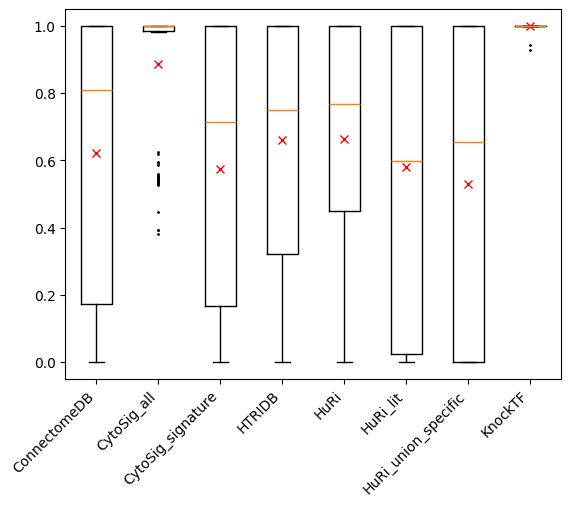

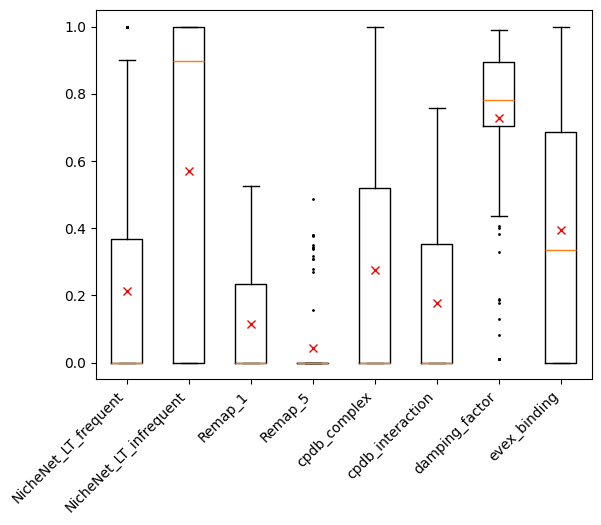

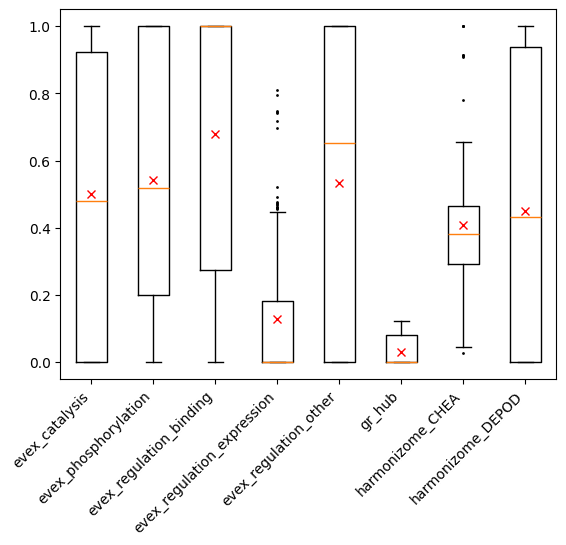

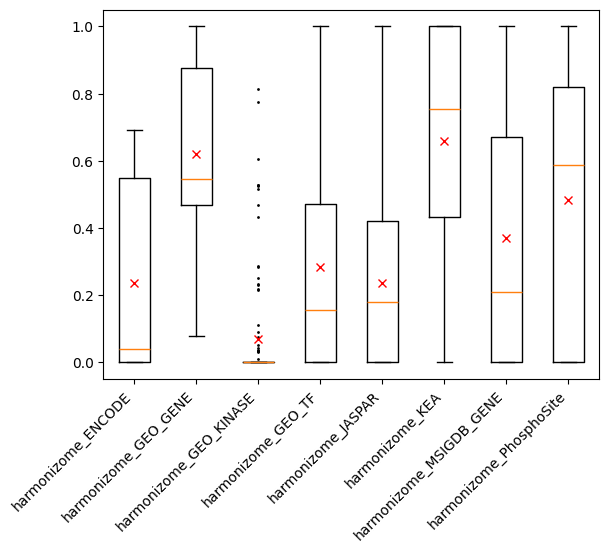

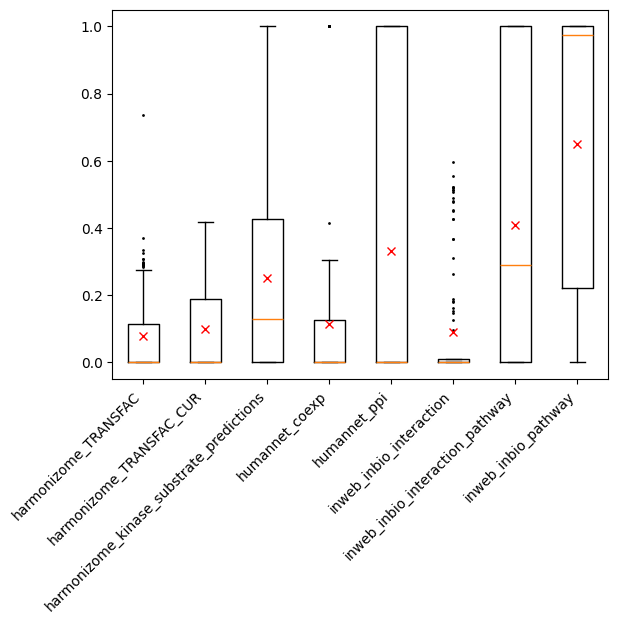

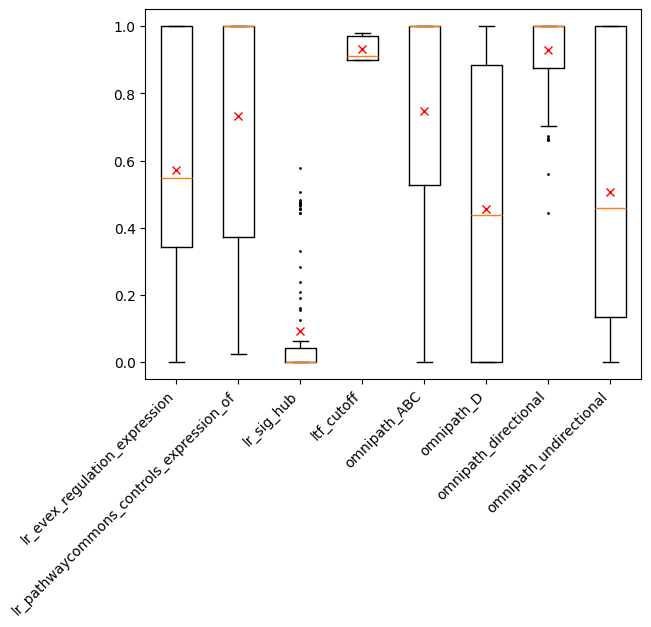

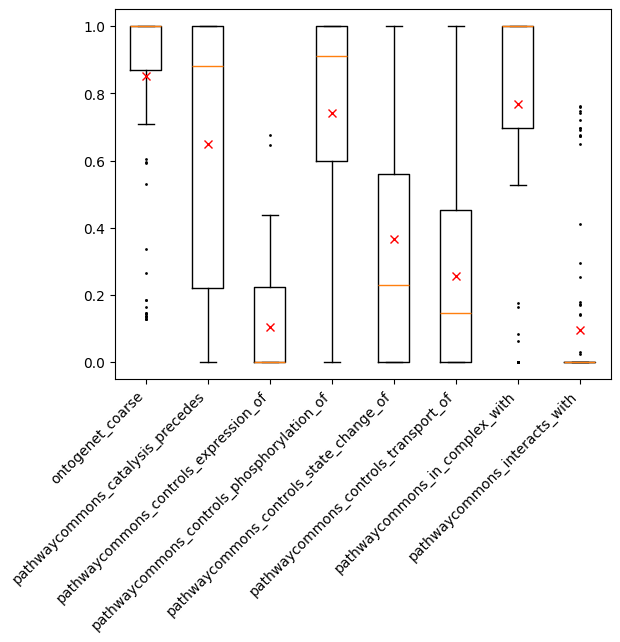

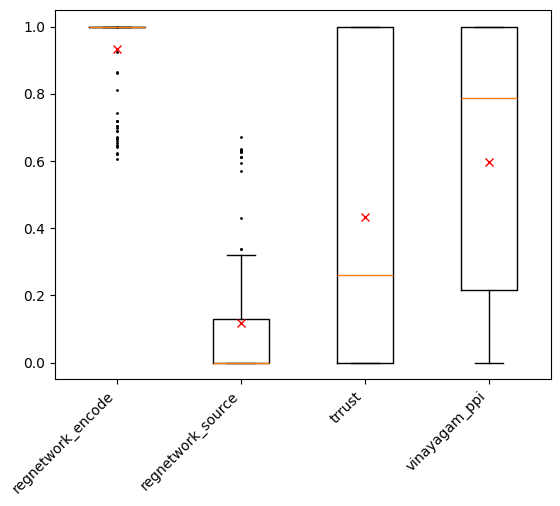

In [7]:
sws = list(sw for _, _, sw in ranked_solutions)
sws = sorted(
    reduce(lambda x, y : combine_dicts(x, y, lambda x, y : tuple(chain(x, (y,)))), sws[1:], dict((k, (v,))for k, v in sws[0].items())).items(),
    key=lambda x : x[0]
)
avgs = sorted(
    average_solution.items(),
    key=lambda x : x[0]
)
chunk_size = 8
for i in range(0, len(sws), chunk_size):
    sws_chunk = sws[i:i+chunk_size]
    avgs_chunk = avgs[i:i+chunk_size]
    labels, vals = zip(*sws_chunk)
    plt.boxplot(vals, tick_labels=labels, flierprops={'marker': '.', 'markersize': 2})
    plt.xticks(rotation=45, ha='right')
    name2id = dict(zip((e[0] for e in avgs_chunk), range(1, chunk_size + 1)))
    for k, v in avgs_chunk:
        plt.plot(name2id[k], v, "rx")
    plt.show()

separate the hyperparameters from the source weights

In [8]:
lr_sig_hub = average_solution.pop("lr_sig_hub")
gr_hub = average_solution.pop("gr_hub")
ltf_cutoff = average_solution.pop("ltf_cutoff")
damping_factor = average_solution.pop("damping_factor")

## Human Model

In [9]:
network_path = os.path.normpath("./tutorial_files/model_construction/human")
if not os.path.exists(network_path):
    os.makedirs(network_path)
for filename in (
    "gr_human.csv",
    "lr_network_human.csv",
    "lr_sig_human.csv"
):
    file_path = os.path.join(network_path, filename)
    if not os.path.exists(file_path):
        res = requests.get(f"https://zenodo.org/records/14929618/files/{filename}")
        with open(file_path, "wb") as file:
            file.write(res.content)

In [10]:
gr_network = pd.DataFrame(read_csv_cols(os.path.join(network_path, "gr_human.csv")))
lr_network = pd.DataFrame(read_csv_cols(os.path.join(network_path, "lr_network_human.csv")))
sig_network = pd.DataFrame(read_csv_cols(os.path.join(network_path, "lr_sig_human.csv")))

In [11]:
weighted_networks = construct_weighted_networks(
    lr_network,
    sig_network,
    gr_network,
    aggregated_solution
)
weighted_networks["lr_sig"] = apply_hub_correction(weighted_networks["lr_sig"], hub=lr_sig_hub)
weighted_networks["gr"] = apply_hub_correction(weighted_networks["gr"], hub=gr_hub)
lt_matrix, ltf_matrix, grn_matrix = construct_ligand_target_matrix(
    weighted_networks,
    lr_network,
    set(lr_network["from"]),
    damping_factor=damping_factor,
    ltf_cutoff=ltf_cutoff,
    return_all_matrices=True
)
mat, row_names, col_names = lt_matrix
# convert to column-major memory layout
predictor = LigandActivityPredictor(
    np.array(mat, order="F"),
    row_names,
    col_names
)
ltf_matrix = (csr_matrix(ltf_matrix[0]), ltf_matrix[1], ltf_matrix[2])

In [13]:
# path to the directory where you want to save the model
model_path = f"D:/Data/nichenetpy/model_optimization/model/{model_version}/{model_type}/human"
if not os.path.exists(model_path):
    os.makedirs(model_path)
with open(os.path.join(model_path, f"nichenet_human_{model_version}_{tag}.pkl"), "wb") as file:
    file.write(pickle.dumps({
        "predictor": predictor,
        "lr_network": LigandReceptorNetwork(lr_network),
        "lr_sig": WeightedNetwork(weighted_networks["lr_sig"]),
        "gr": WeightedNetwork(weighted_networks["gr"]),
        "ltf_matrix": ltf_matrix,
        "grn_matrix": grn_matrix,
        "source_weights": average_solution
    }))

## Mouse Model

In [14]:
network_path = os.path.normpath("./tutorial_files/model_construction/mouse")
if not os.path.exists(network_path):
    os.makedirs(network_path)
for filename in (
    "gr_mouse.csv",
    "lr_network_mouse.csv",
    "lr_sig_mouse.csv"
):
    file_path = os.path.join(network_path, filename)
    if not os.path.exists(file_path):
        res = requests.get(f"https://zenodo.org/records/14929618/files/{filename}")
        with open(file_path, "wb") as file:
            file.write(res.content)

In [15]:
gr_network = pd.DataFrame(read_csv_cols(os.path.join(network_path, "gr_mouse.csv")))
lr_network = pd.DataFrame(read_csv_cols(os.path.join(network_path, "lr_network_mouse.csv")))
sig_network = pd.DataFrame(read_csv_cols(os.path.join(network_path, "lr_sig_mouse.csv")))

In [16]:
weighted_networks = construct_weighted_networks(
    lr_network,
    sig_network,
    gr_network,
    aggregated_solution
)
weighted_networks["lr_sig"] = apply_hub_correction(weighted_networks["lr_sig"], hub=lr_sig_hub)
weighted_networks["gr"] = apply_hub_correction(weighted_networks["gr"], hub=gr_hub)
lt_matrix, ltf_matrix, grn_matrix = construct_ligand_target_matrix(
    weighted_networks,
    lr_network,
    set(lr_network["from"]),
    damping_factor=damping_factor,
    ltf_cutoff=ltf_cutoff,
    return_all_matrices=True
)
mat, row_names, col_names = lt_matrix
# convert to column-major memory layout
predictor = LigandActivityPredictor(
    np.array(mat, order="F"),
    row_names,
    col_names
)
ltf_matrix = (csr_matrix(ltf_matrix[0]), ltf_matrix[1], ltf_matrix[2])

In [ ]:
# path to the directory where you want to save the model
model_path = f"D:/Data/nichenetpy/model_optimization/model/{model_version}/{model_type}/mouse"
if not os.path.exists(model_path):
    os.makedirs(model_path)
with open(os.path.join(model_path, f"nichenet_mouse_{model_version}_{tag}.pkl"), "wb") as file:
    file.write(pickle.dumps({
        "predictor": predictor,
        "lr_network": LigandReceptorNetwork(lr_network),
        "lr_sig": WeightedNetwork(weighted_networks["lr_sig"]),
        "gr": WeightedNetwork(weighted_networks["gr"]),
        "source_weights": aggregated_solution,
        "ltf_matrix": ltf_matrix,
        "grn_matrix": grn_matrix,
    }))

In [18]:
session_info.show()